In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import optuna

from datasets import Dataset, DatasetDict

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer

import evaluate

In [65]:
train_df = pd.read_csv('data/train.csv')
valid_df = pd.read_csv('data/valid.csv')


In [66]:
# Prepare datasets
train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

ds = DatasetDict({
    'train': train_ds,
    'validation': valid_ds
})

label_list = sorted(ds["train"].unique("label"))
num_labels = len(label_list)

label_to_id = {label: idx for idx, label in enumerate(label_list)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

In [67]:
# Initialize tokenizer
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def concat_fields(batch):
    text_cols = [c for c in ds["train"].column_names
             if c not in {"label", "item", "text"}] 
    
    batch["text"] = [
        " [SEP] ".join(str(batch[col][i]) for col in text_cols)  # one long string per item
        for i in range(len(batch[text_cols[0]]))
    ]
    return batch

def tokenize(batch):
    return tokenizer(batch["text"], padding='max_length', truncation=True, max_length=512)


print(f"Dataset columns: {ds['train'].column_names}")
ds = ds.remove_columns(["text"]) if "text" in ds.column_names else ds
ds = ds.map(concat_fields, batched=True)
print(f"Dataset columns: {ds['train'].column_names}")

# Sample the first item from the dataset
sample_item = ds["train"][0]

# Examine the text field (concatenated fields)
print("\nSample text field:")
print(sample_item["text"])

tokenized_dataset = ds.map(tokenize, batched=True)

Dataset columns: ['item', 'name', 'description', 'type', 'category', 'subcategory', 'label']


Map: 100%|██████████| 300/300 [00:00<00:00, 82096.38 examples/s]


Dataset columns: ['item', 'name', 'description', 'type', 'category', 'subcategory', 'label', 'text']

Sample text field:
916 [SEP] 2012 film by M. Mohanan [SEP] entity [SEP] films [SEP] film


Map: 100%|██████████| 300/300 [00:00<00:00, 16728.81 examples/s]


In [68]:
# Map labels to IDs
def encode_labels(batch):
    batch['labels'] = [label_to_id[label] for label in batch['label']]
    return batch

tokenized_dataset = tokenized_dataset.map(encode_labels, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['label', 'description'])
collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)
tokenized_dataset.set_format(type='torch')


def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id_to_label,
        label2id=label_to_id
    )

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 5e-5, log=True),
        "weight_decay":  trial.suggest_float("weight_decay", 0.0, 0.1),
        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size", [16, 32]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5),
    }

Map: 100%|██████████| 300/300 [00:00<00:00, 97716.18 examples/s]


In [73]:
# Prepare metrics and training arguments
metric_accuracy = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = metric_accuracy.compute(predictions=predictions, references=labels)['accuracy']
    f1 = metric_f1.compute(predictions=predictions, references=labels, average='weighted')['f1']
    return {"accuracy": accuracy, "f1": f1}

def compute_objective(metrics):
    # eval_*
    return metrics["eval_f1"]

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

""" batch_size = 32
learning_rate = 5e-5
weight_decay = 0.01
epochs = 3

training_args = TrainingArguments(
    output_dir="training_dir",                    # output directory [Mandatory]
    num_train_epochs=epochs,                      # total number of training epochs
    per_device_train_batch_size=batch_size,       # batch size per device during training
    warmup_steps=500,                             # number of warmup steps for learning rate scheduler
    weight_decay=weight_decay,                    # strength of weight decay
    save_strategy="no",
    learning_rate=learning_rate,                  # learning rate
    report_to="none",
    logging_dir="./logs"                          # use it later to get the training curves
) """

training_args = TrainingArguments(
    output_dir = "hpo_runs",
    eval_strategy            = "steps",
    save_strategy            = "steps",
    logging_strategy         = "steps",
    save_total_limit         = 2,
    load_best_model_at_end   = True,
    metric_for_best_model    = "f1",
    report_to                = "none",
)

trainer = Trainer(
    args            = training_args,
    model_init      = model_init,
    train_dataset   = tokenized_dataset["train"],
    eval_dataset    = tokenized_dataset["validation"],
    tokenizer       = tokenizer,
    data_collator   = collator,
    compute_metrics = compute_metrics,
)

best_trial = trainer.hyperparameter_search(
    backend           = "optuna",
    hp_space          = optuna_hp_space,
    n_trials          = 30,
    direction         = "maximize",
    compute_objective = compute_objective,
)

print("Best run:", best_trial)

Using device: mps


/var/folders/sx/6fb334k95yv2g4zrkgnswy6h0000gn/T/ipykernel_15509/3530787367.py:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-05-01 15:55:35,567] A new study created in memory with name: no-name-d76cf8a1-7ce9-40d1-baea-55a8d121fc39
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.684700,0.637988,0.733333,0.721883
1000,0.482300,0.637978,0.760000,0.750314
1500,0.432300,0.612575,0.760000,0.752599


[I 2025-05-01 16:16:43,611] Trial 0 finished with value: 0.7525993220192597 and parameters: {'learning_rate': 5.804442437571397e-06, 'weight_decay': 0.08407321509384663, 'per_device_train_batch_size': 16, 'num_train_epochs': 5}. Best is trial 0 with value: 0.7525993220192597.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy,F1
500,0.588400,0.646736,0.750000,0.739991
1000,0.384600,0.681928,0.763333,0.757427
1500,0.297900,0.693149,0.776667,0.771759


...

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.574400,0.643011,0.770000,0.762111
1000,0.365500,0.665604,0.770000,0.764562


[I 2025-05-01 20:55:10,805] Trial 28 finished with value: 0.7645623218152192 and parameters: {'learning_rate': 1.9874357647535058e-05, 'weight_decay': 0.03012866587044595, 'per_device_train_batch_size': 16, 'num_train_epochs': 3}. Best is trial 12 with value: 0.7789876867455315.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy,F1
500,0.750700,0.646547,0.713333,0.700811


[I 2025-05-01 21:00:56,262] Trial 29 pruned. 


Best run: BestRun(run_id='12', objective=0.7789876867455315, hyperparameters={'learning_rate': 1.7655538436252286e-05, 'weight_decay': 0.04310355592648939, 'per_device_train_batch_size': 16, 'num_train_epochs': 4}, run_summary=None)


In [114]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix
)

In [108]:
label_names = ["agnostic", "representative", "exclusive"]

A more specific compute metrics function to allow the calculation of metrics for each class separately

In [109]:
label_ids   = list(range(len(label_names)))   # [0, 1, 2]

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    # overall scores
    metrics = {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

    # per-class scores
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=label_ids,
        zero_division=0
    )
    for i, name in enumerate(label_names):
        metrics[f"precision_{name}"] = prec[i]
        metrics[f"recall_{name}"]    = rec[i]
        metrics[f"f1_{name}"]        = f1[i]

    return metrics

In [110]:
best_args = TrainingArguments(
    output_dir = "final_training_dir",
    eval_strategy = "steps",
    load_best_model_at_end = True,
    learning_rate   = best_trial.hyperparameters["learning_rate"],
    weight_decay    = best_trial.hyperparameters["weight_decay"],
    per_device_train_batch_size = best_trial.hyperparameters["per_device_train_batch_size"],
    num_train_epochs = best_trial.hyperparameters["num_train_epochs"],
)

final_trainer = Trainer(
    args            = best_args,
    model_init      = model_init,
    train_dataset   = tokenized_dataset["train"],
    eval_dataset    = tokenized_dataset["validation"],
    tokenizer       = tokenizer,
    data_collator   = collator,
    compute_metrics = compute_metrics,
)


/var/folders/sx/6fb334k95yv2g4zrkgnswy6h0000gn/T/ipykernel_15509/1232848991.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [111]:
final_trainer.train()
final_trainer.save_model("lm_model/final_model")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Agnostic,Recall Agnostic,F1 Agnostic,Precision Representative,Recall Representative,F1 Representative,Precision Exclusive,Recall Exclusive,F1 Exclusive
500,0.581900,0.632894,0.756667,0.747076,0.850746,0.974359,0.908367,0.612903,0.750000,0.674556,0.767123,0.523364,0.622222
1000,0.367800,0.704695,0.756667,0.748501,0.860465,0.948718,0.902439,0.598039,0.802632,0.685393,0.797101,0.514019,0.625000
1500,0.270500,0.716186,0.780000,0.774897,0.861538,0.957265,0.906883,0.655172,0.750000,0.699387,0.783133,0.607477,0.684211


In [112]:
final_trainer.evaluate()

{'eval_loss': 0.6328943967819214,
 'eval_accuracy': 0.7566666666666667,
 'eval_f1_weighted': 0.7470764480975943,
 'eval_precision_agnostic': 0.8507462686567164,
 'eval_recall_agnostic': 0.9743589743589743,
 'eval_f1_agnostic': 0.9083665338645418,
 'eval_precision_representative': 0.6129032258064516,
 'eval_recall_representative': 0.75,
 'eval_f1_representative': 0.6745562130177515,
 'eval_precision_exclusive': 0.7671232876712328,
 'eval_recall_exclusive': 0.5233644859813084,
 'eval_f1_exclusive': 0.6222222222222222,
 'eval_runtime': 3.6697,
 'eval_samples_per_second': 81.751,
 'eval_steps_per_second': 10.355,
 'epoch': 4.0}

In [113]:
pred = final_trainer.predict(tokenized_dataset["validation"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=-1)
print(classification_report(
        y_true, y_pred,
        target_names=label_names,
        zero_division=0))

                precision    recall  f1-score   support

      agnostic       0.85      0.97      0.91       117
representative       0.61      0.75      0.67        76
     exclusive       0.77      0.52      0.62       107

      accuracy                           0.76       300
     macro avg       0.74      0.75      0.74       300
  weighted avg       0.76      0.76      0.75       300



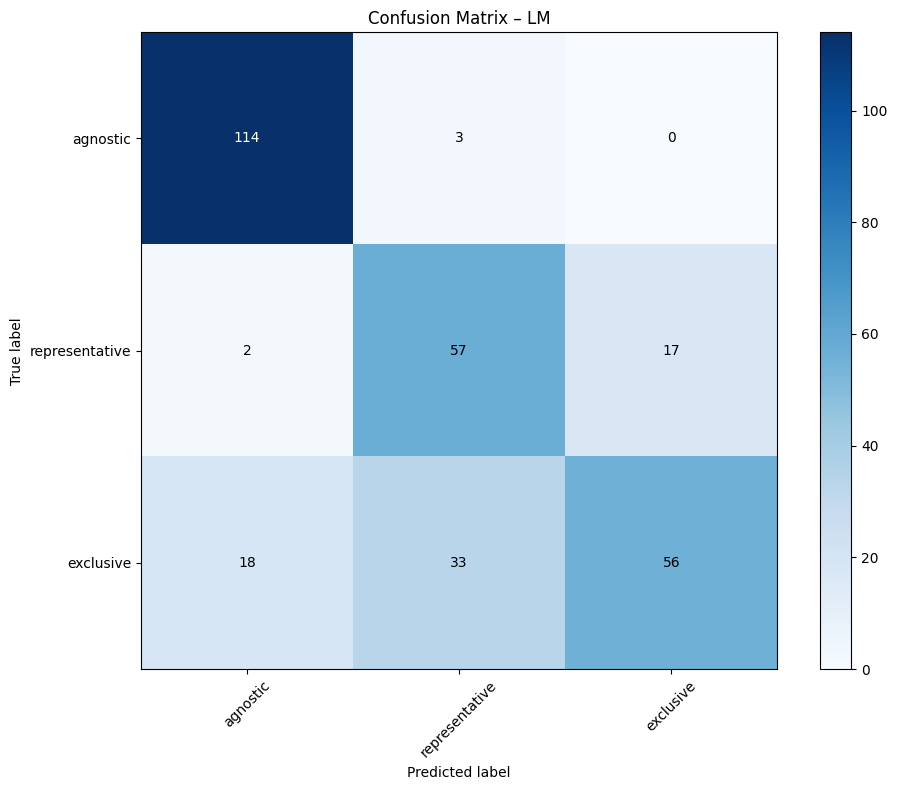

In [115]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix – LM')
plt.colorbar()

# tick marks and labels
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45)
plt.yticks(tick_marks, label_names)

# text annotations
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [116]:
MODEL_DIR = "lm_model/final_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval() 

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [117]:
test_df = pd.read_csv("data/test_unlabeled.csv")
text_cols = [c for c in test_df.columns if c not in {"label", "item", "text"}]

def concat_fields(example):
    example["text"] = " [SEP] ".join(str(example[col]) for col in text_cols)
    return example

test_ds = Dataset.from_pandas(test_df)
test_ds = test_ds.map(concat_fields)

Map: 100%|██████████| 300/300 [00:00<00:00, 9380.36 examples/s]


In [118]:
test_ds = test_ds.map(tokenize, batched=True)
test_ds = test_ds.remove_columns(
            [c for c in test_ds.column_names
             if c not in tokenizer.model_input_names])
test_ds.set_format(type="torch")

Map: 100%|██████████| 300/300 [00:00<00:00, 4742.33 examples/s]


In [119]:
trainer = Trainer(model=model, tokenizer=tokenizer)
raw_preds = trainer.predict(test_ds).predictions
pred_ids  = np.argmax(raw_preds, axis=1)

id2label   = model.config.id2label
pred_labels = [id2label[int(i)] for i in pred_ids]

/var/folders/sx/6fb334k95yv2g4zrkgnswy6h0000gn/T/ipykernel_15509/1737958799.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


In [120]:
# Add predicted labels to test_df
test_df["label"] = pred_labels

# Keep all the columns in the output file
FILENAME = "Saffron_Mafia_output_modello2.csv"
test_df.to_csv(FILENAME, index=False)
print("Predictions written to", FILENAME)
test_df.head()

Predictions written to Saffron_Mafia_output_modello2.csv


,item,name,description,type,category,subcategory,label
0,http://www.wikidata.org/entity/Q2427430,Northeast Flag Replacement,Zhang Xueliang's announcement on 29 December 1...,concept,History,historical event,cultural exclusive
1,http://www.wikidata.org/entity/Q125482,imam,Islamic leadership position,concept,philosophy and religion,religious leader,cultural representative
2,http://www.wikidata.org/entity/Q15789,FC Bayern Munich,"association football club in Munich, Germany",named entity,sports,sports club,cultural exclusive
3,http://www.wikidata.org/entity/Q582496,Fome Zero,program intended to eradicate hunger and extre...,named entity,politics,government agency,cultural exclusive
4,http://www.wikidata.org/entity/Q572811,Anthony Award,awards given at Bouchercon for mystery literature,named entity,Literature,literary award,cultural exclusive
